# Import Required Libraries

In [1]:
%pip install tqdm tabulate --quiet
%pip install --upgrade pip
import subprocess
import sys
import importlib
from tqdm import tqdm
import time
import tabulate

# List of required libraries
required_libraries = [
    "numpy", "pandas", "matplotlib", "seaborn",
    "tensorflow", "scikit-learn"
]

print("🔍 Checking and installing missing Python packages...\n")

# Iterate through packages with progress bar
for package in tqdm(required_libraries, desc="📦 Installing Dependencies", ncols=80):
    try:
        importlib.import_module(package)
        tqdm.write(f"✅ {package} is already installed.")
    except ImportError:
        tqdm.write(f"📥 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
        time.sleep(0.5)  # Just to make progress visually smoother
        tqdm.write(f"✅ {package} installed successfully!")

print("\n🚀 All dependencies are ready!\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from datetime import datetime
import json

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
🔍 Checking and installing missing Python packages...



📦 Installing Dependencies:  17%|██▊              | 1/6 [00:00<00:01,  3.58it/s]

✅ numpy is already installed.


📦 Installing Dependencies:  33%|█████▋           | 2/6 [00:01<00:02,  1.39it/s]

✅ pandas is already installed.


...

✅ seaborn is already installed.


📦 Installing Dependencies:  83%|██████████████▏  | 5/6 [00:13<00:04,  4.01s/it]

✅ tensorflow is already installed.
📥 Installing scikit-learn...


📦 Installing Dependencies: 100%|█████████████████| 6/6 [00:14<00:00,  2.46s/it]


✅ scikit-learn installed successfully!

🚀 All dependencies are ready!



# Version Info

In [2]:

print(f"\n🧠 TensorFlow version: {tf.__version__}")
print(f"🧩 Keras version: {keras.__version__}")
print("✅ Libraries imported successfully and environment is ready!")


🧠 TensorFlow version: 2.20.0
🧩 Keras version: 3.11.3
✅ Libraries imported successfully and environment is ready!


# Load Dataset

📂 Total classes found: 89

📁 Classes and Image Counts:
 1. Acne Keloidalis Nuchae    — 147 images
 2. Actinic Cheilitis         — 165 images
 3. Acute Paronychia          — 138 images
 4. Allergic Contact Dermatitis — 105 images
 5. Alopecia Areata           — 166 images
 6. Angiokeratomas            — 172 images
 7. Benign Familial Chronic Pemphigus — 156 images
 8. Beriberi                  — 616 images
 9. Blood Cloth Problems      — 546 images
10. Bullous pemphigoid        — 156 images
11. Candidiasis               — 198 images
12. Candidiasis-Large-Skin-Folds — 184 images
13. Chronic Paronychia        — 156 images
14. Cutaneous Herpes          — 164 images
15. Dariers Disease           — 104 images
16. Dermographism             — 128 images
17. Distal Subungual Onychomycosis — 105 images
18. Drug Eruptions            — 156 images
19. Eczema                    — 710 images
20. Eczema Herpeticum         — 192 images
21. Epidermolysis Bullosa     — 150 images
22. Erythema Multiforme 

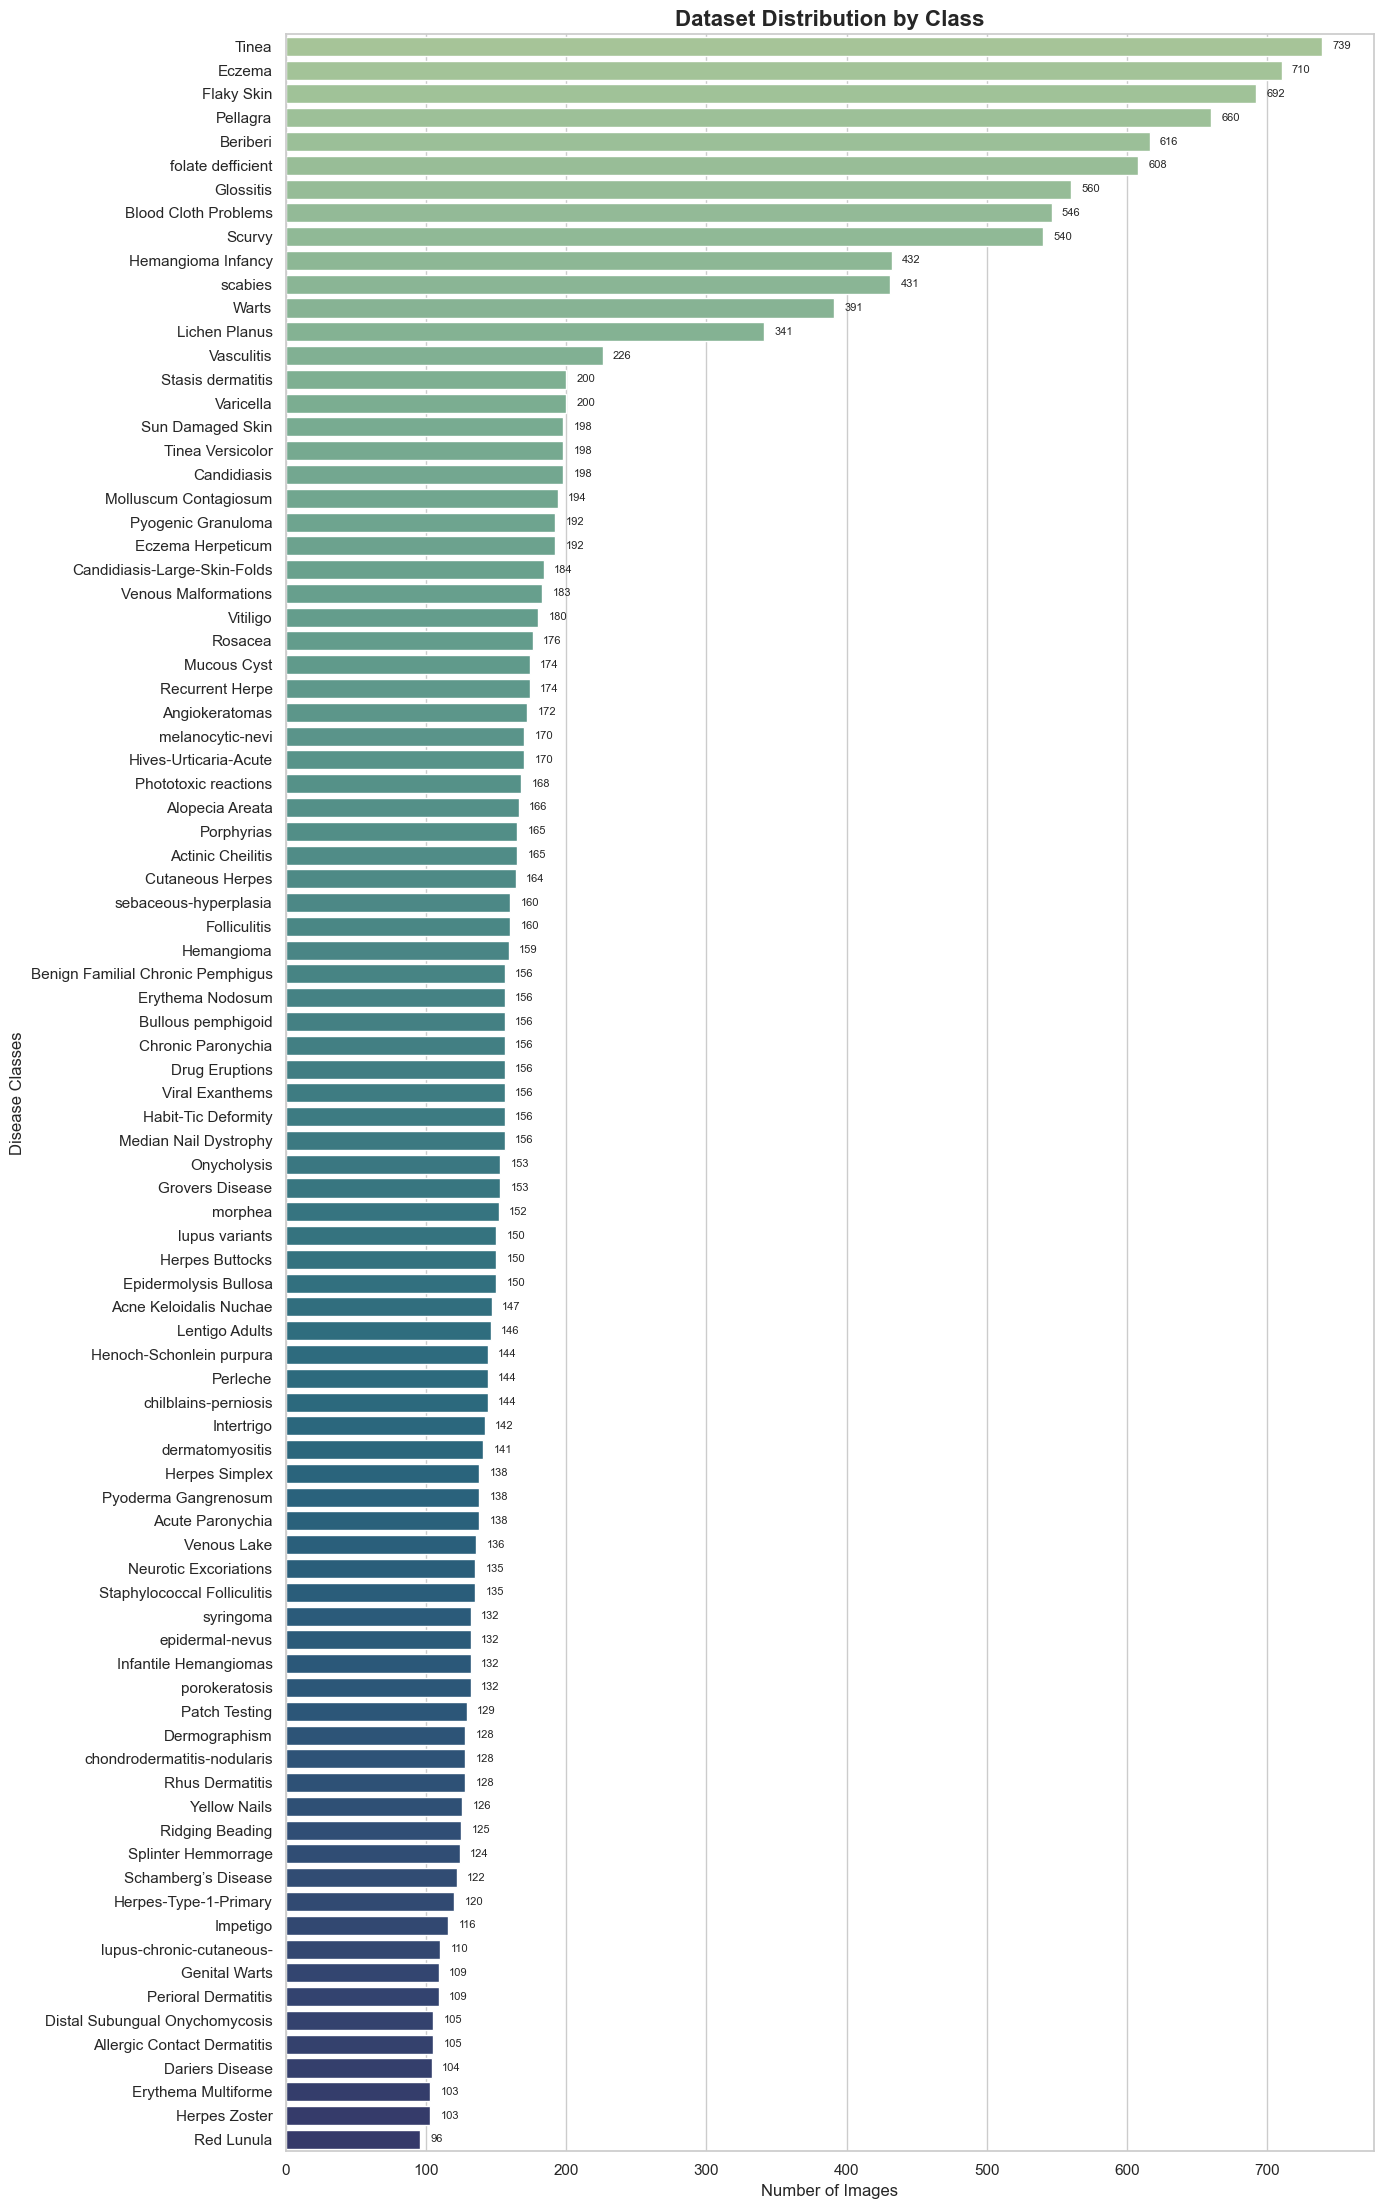

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

# Suppress font and seaborn warnings
warnings.filterwarnings("ignore", message="Glyph")
warnings.filterwarnings("ignore", message="Passing `palette` without assigning `hue`")

data_path = './Backend/Dataset'  # Adjust this path as needed

if not os.path.exists(data_path):
    raise FileNotFoundError(f"❌ Dataset path not found: {data_path}")

# Get all class folders (ignore hidden)
class_folders = sorted([
    f for f in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, f)) and not f.startswith('.')
])

print(f"📂 Total classes found: {len(class_folders)}")
print("\n📁 Classes and Image Counts:")

# Count images per class
class_counts = {}
for idx, class_name in enumerate(class_folders, 1):
    class_path = os.path.join(data_path, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    class_counts[class_name] = len(images)
    print(f"{idx:2d}. {class_name:<25} — {len(images)} images")

# Convert to DataFrame for sorting
df_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"]).sort_values("Count", ascending=False)

# Summary stats
total_images = df_counts["Count"].sum()
avg_images = df_counts["Count"].mean()

print(f"\n📸 Total images: {total_images}")
print(f"📊 Average images per class: {avg_images:.1f}")


sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, max(10, len(df_counts) * 0.25)))

# Horizontal barplot
ax = sns.barplot(
    data=df_counts,
    y="Class",
    x="Count",
    hue="Class",             # Required for future Seaborn versions
    dodge=False,
    palette="crest",
    legend=False
)

# Add count labels
for i, value in enumerate(df_counts["Count"]):
    ax.text(value + max(df_counts["Count"]) * 0.01, i, str(value), va='center', fontsize=8)

# Labels and title
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Disease Classes", fontsize=12)
plt.title("Dataset Distribution by Class", fontsize=16, fontweight="bold")

plt.tight_layout()

# Save the figure
plt.savefig("dataset_distribution.png", dpi=300)
print("\n💾 Chart saved as: dataset_distribution.png")

plt.show()


# Data Preprocessing & Augmentation

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
img_height, img_width = 224, 224
batch_size = 32
validation_split = 0.2

print(f"🖼 Image size: {img_height}x{img_width}")
print(f"📦 Batch size: {batch_size}")
print(f"🧩 Validation split: {validation_split * 100}%")

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=validation_split
)

print("✅ Data generators configured successfully!")


🖼 Image size: 224x224
📦 Batch size: 32
🧩 Validation split: 20.0%
✅ Data generators configured successfully!


# Create Training and Validation Datasets

In [6]:
# ============================================
# Create Training and Validation Generators (RGB Mode)
# ============================================

train_generator = train_datagen.flow_from_directory(
    data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',        # 👈 Force 3-channel RGB input
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',    
    subset='validation',
    shuffle=False,
    seed=42
)

# ============================================
# Class Information
# ============================================

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\n📚 Found {train_generator.samples} training images")
print(f"🧪 Found {val_generator.samples} validation images")
print(f"🧩 Number of classes: {num_classes}")
print(f"🏷 First 10 classes: {class_names[:10]} ...")
print(f"🖼 Input shape from generator: {train_generator.image_shape}")


Found 14956 images belonging to 89 classes.
Found 3700 images belonging to 89 classes.

📚 Found 14956 training images
🧪 Found 3700 validation images
🧩 Number of classes: 89
🏷 First 10 classes: ['Acne Keloidalis Nuchae', 'Actinic Cheilitis', 'Acute Paronychia', 'Allergic Contact Dermatitis', 'Alopecia Areata', 'Angiokeratomas', 'Benign Familial Chronic Pemphigus', 'Beriberi', 'Blood Cloth Problems', 'Bullous pemphigoid'] ...
🖼 Input shape from generator: (224, 224, 3)


# Visualize Sample Images

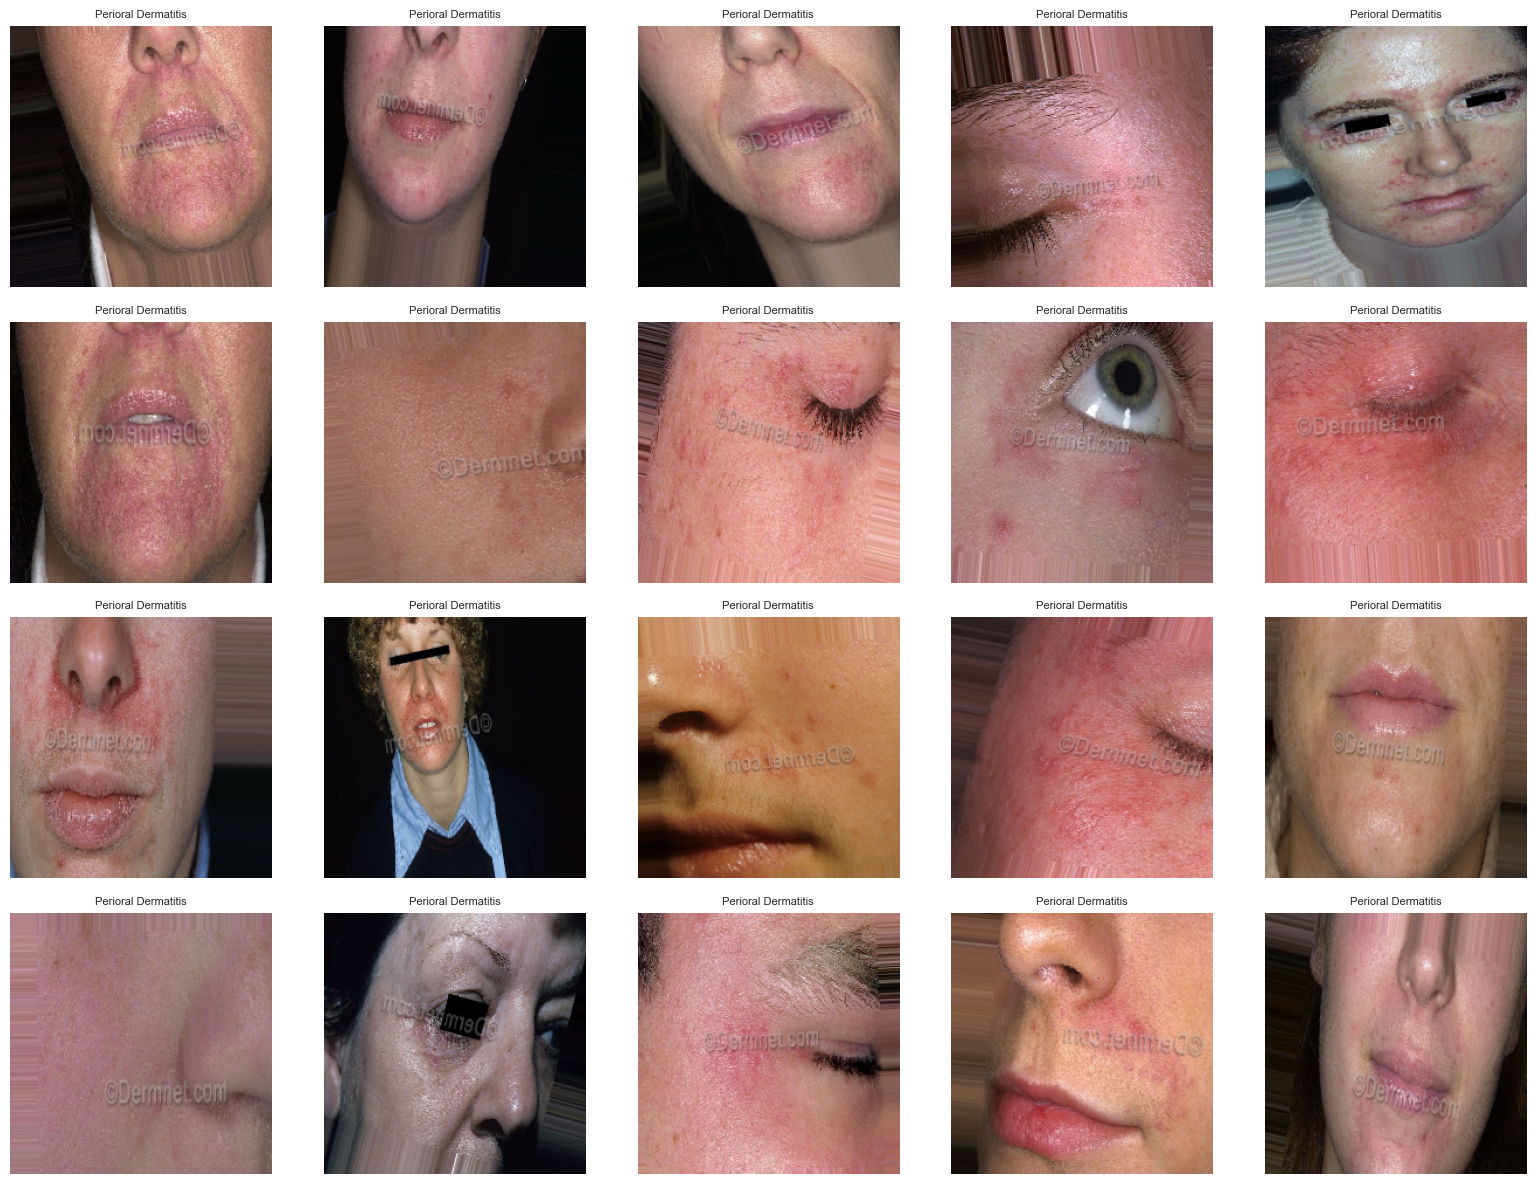

✓ Displayed 20 sample images from 'Perioral Dermatitis' class.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

target_class = "Perioral Dermatitis"

if target_class not in class_names:
    raise ValueError(f"❌ Class '{target_class}' not found in dataset!")

target_index = class_names.index(target_class)

# Gather sample images for the target class
sample_images = []
sample_labels = []

# We only need a few samples; stop after enough found
for _ in range(len(train_generator)):
    img_batch, label_batch = next(train_generator)
    for img, label in zip(img_batch, label_batch):
        if np.argmax(label) == target_index:
            sample_images.append(img)
            sample_labels.append(target_class)
            if len(sample_images) >= 20:
                break
    if len(sample_images) >= 20:
        break

plt.figure(figsize=(16, 12))
for i, img in enumerate(sample_images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(target_class, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Reset generator for training use again
train_generator.reset()

print(f"✓ Displayed {len(sample_images)} sample images from '{target_class}' class.")


# Build CNN Model with Transfer Learning

In [16]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow import keras
from tabulate import tabulate
import numpy as np
import os

print("🔧 Building EfficientNetB0 model...")

# Define your parameters
img_height, img_width = 224, 224

# Optional: create folder for weights if missing
os.makedirs('./Backend/Processing_Model', exist_ok=True)

# Check for local weights
local_weights_path = './Backend/Processing_Model/efficientnetb0_notop.h5'
use_local_weights = os.path.exists(local_weights_path)

if use_local_weights:
    print(f"⚠️  Found local EfficientNet weights: {local_weights_path}")
    print("→ Initializing model without weights and loading manually...")

    base_model = EfficientNetB0(
        include_top=False,
        weights=None,
        input_shape=(img_height, img_width, 3),
        pooling='avg'
    )

    print("⏳ Loading local weights...")
    base_model.load_weights(local_weights_path)
    print("✅ Local EfficientNet weights loaded successfully!")
else:
    print("🌐 Downloading ImageNet pretrained EfficientNetB0 weights...")
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_height, img_width, 3),
        pooling='avg'
    )
    print("✅ ImageNet weights loaded successfully!")

base_model.trainable = False
print(f"🔒 Base model frozen — {len(base_model.layers)} layers non-trainable.")


inputs = Input(shape=(img_height, img_width, 3))
x = base_model(inputs, training=False)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs, name="EfficientNetB0_SkinClassifier")

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🧠 Model Architecture:")
print("=" * 70)

# Collect layer info for ASCII table
table_data = []
for layer in model.layers:
    name = layer.name
    # ✅ Safe output shape handling
    output_shape = getattr(layer, 'output_shape', 'N/A')
    params = f"{layer.count_params():,}"
    table_data.append([name, str(output_shape), params])

# Add totals
total_params = f"{model.count_params():,}"
trainable_params = f"{np.sum([keras.backend.count_params(w) for w in model.trainable_weights]):,}"
non_trainable_params = f"{np.sum([keras.backend.count_params(w) for w in model.non_trainable_weights]):,}"

table_data.append(["─" * 40, "─" * 20, "─" * 10])
table_data.append(["Total Parameters", "", total_params])
table_data.append(["Trainable Parameters", "", trainable_params])
table_data.append(["Non-trainable Parameters", "", non_trainable_params])

model_path = "./Backend/Model/vitamin_deficiency_model.h5"
model = load_model(model_path)
model.summary()

# Print table
print(tabulate(table_data, headers=["Layer (type)", "Output Shape", "Parameters"], tablefmt="fancy_grid"))
print("\n✅ Model built and compiled successfully!")



🔧 Building EfficientNetB0 model...
🌐 Downloading ImageNet pretrained EfficientNetB0 weights...
✅ ImageNet weights loaded successfully!
🔒 Base model frozen — 239 layers non-trainable.

🧠 Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 89)             │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,725,595 (246.91 MB)

 Trainable params: 64,577,753 (246.34 MB)

 Non-trainable params: 147,840 (577.50 KB)

 Optimizer params: 2 (12.00 B)

╒══════════════════════════════════════════╤══════════════════════╤══════════════╕
│ Layer (type)                             │ Output Shape         │ Parameters   │
╞══════════════════════════════════════════╪══════════════════════╪══════════════╡
│ input_layer_5                            │ N/A                  │ 0            │
├──────────────────────────────────────────┼──────────────────────┼──────────────┤
│ efficientnetb0                           │ (None, 1280)         │ 4,049,571    │
├──────────────────────────────────────────┼──────────────────────┼──────────────┤
│ batch_normalization_2                    │ N/A                  │ 5,120        │
├──────────────────────────────────────────┼──────────────────────┼──────────────┤
│ dense_6                                  │ N/A                  │ 655,872      │
├──────────────────────────────────────────┼──────────────────────┼──────────────┤
│ dropout_4                                │ N/A                  │ 0            │
├───

# Train the Model

In [ ]:
# Training parameters
epochs = 25

print("="*60)
print("STARTING MODEL TRAINING")
print("="*60)
print(f"Epochs: {epochs}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Steps per epoch: {train_generator.samples // batch_size}")
print("="*60)

# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")

print("\n" + "="*60)
print("✓ MODEL TRAINING COMPLETE")
print("="*60)

STARTING MODEL TRAINING
Epochs: 25
Training samples: 14924
Validation samples: 3728
Steps per epoch: 466

Epoch 1/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 303s 676ms/step - accuracy: 0.4833 - loss: 1.4805 - val_accuracy: 0.6320 - val_loss: 1.1598
Epoch 2/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 281s 676ms/step - accuracy: 0.5065 - loss: 1.4047 - val_accuracy: 0.6452 - val_loss: 1.0980
Epoch 3/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 294s 678ms/step - accuracy: 0.5294 - loss: 1.3411 - val_accuracy: 0.6617 - val_loss: 1.0238
Epoch 4/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 316s 643ms/step - accuracy: 0.5516 - loss: 1.2958 - val_accuracy: 0.6742 - val_loss: 0.9606
Epoch 5/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 299s 699ms/step - accuracy: 0.5681 - loss: 1.2434 - val_accuracy: 0.6878 - val_loss: 0.8798
Epoch 6/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 279s 713ms/step - accuracy: 0.5864 - loss: 1.1842 - val_accuracy: 0.7041 - val_loss: 0.8069
Epoch 7/25
466/466 ━━━━━━━━━━━━━━━━━━━━━━━━ 314s 717ms/step - accuracy: 0.6015

# Evaluate Model Performance

In [9]:
import os
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ============================================
# CONFIGURATION
# ============================================
model_path = "./Backend/Model/vitamin_deficiency_model.h5"           # path to your saved model
data_path = "./Backend/DataSet"             # path to your validation data folder
class_file = "./Backend/Model/class.json"  # or your existing JSON
img_height, img_width = 224, 224
batch_size = 32
validation_split = 0.2

# ============================================
# LOAD MODEL & CLASS NAMES
# ============================================
print("🧠 Loading trained model...")
model = load_model(model_path, compile=False)
print(f"✅ Model loaded successfully from: {model_path}")

# Load class names
if os.path.exists(class_file):
    with open(class_file, 'r') as f:
        class_names = json.load(f)
    print(f"✅ Loaded {len(class_names)} class names from: {class_file}")
else:
    print("⚠️ No class names JSON found — will extract from directory later.")
    class_names = None

# ============================================
# CREATE VALIDATION GENERATOR
# ============================================
val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=validation_split)
val_generator = val_datagen.flow_from_directory(
    data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Use class names from generator if not loaded
if class_names is None:
    class_names = list(val_generator.class_indices.keys())

num_classes = len(class_names)

# ============================================
# PREDICT ON VALIDATION SET
# ============================================
print("\n🔍 Running predictions on validation set...")
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

# ============================================
# CALCULATE METRICS
# ============================================
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f'Validation Accuracy: {accuracy:.4f}')
print(f'F1 Score (Weighted): {f1:.4f}')
print(f'Number of Classes: {num_classes}')
print(f'Total Validation Samples: {len(y_true)}')

# ============================================
# CLASSIFICATION REPORT
# ============================================
print('\n' + "="*60)
print('DETAILED CLASSIFICATION REPORT')
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


🧠 Loading trained model...


c:\Users\darsh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


✅ Model loaded successfully from: ./Backend/Model/vitamin_deficiency_model.h5
✅ Loaded 89 class names from: ./Backend/Model/class.json
Found 3700 images belonging to 89 classes.

🔍 Running predictions on validation set...


c:\Users\darsh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


116/116 ━━━━━━━━━━━━━━━━━━━━ 810s 7s/step

MODEL PERFORMANCE METRICS
Validation Accuracy: 0.9449
F1 Score (Weighted): 0.9446
Number of Classes: 89
Total Validation Samples: 3700

DETAILED CLASSIFICATION REPORT
                                   precision    recall  f1-score   support

           Acne Keloidalis Nuchae     0.8529    1.0000    0.9206        29
                Actinic Cheilitis     1.0000    0.9091    0.9524        33
                 Acute Paronychia     1.0000    1.0000    1.0000        27
      Allergic Contact Dermatitis     0.8696    0.9524    0.9091        21
                  Alopecia Areata     0.9706    1.0000    0.9851        33
                   Angiokeratomas     1.0000    1.0000    1.0000        34
Benign Familial Chronic Pemphigus     1.0000    1.0000    1.0000        31
                         Beriberi     1.0000    1.0000    1.0000       123
             Blood Cloth Problems     1.0000    1.0000    1.0000       109
               Bullous pemphigoid     0

# Confusion Matrix Visualization

🧠 Loading model...
✅ Model loaded successfully from: ./Backend/Model/vitamin_deficiency_model.h5
✅ Loaded 89 class names from: ./Backend/Model/class.json
Found 3700 images belonging to 89 classes.

🔍 Predicting on validation set...
116/116 ━━━━━━━━━━━━━━━━━━━━ 631s 5s/step

MODEL PERFORMANCE METRICS
Validation Accuracy: 0.9449
F1 Score (Weighted): 0.9446
Classes: 89
Validation Samples: 3700

📊 Generating Confusion Matrices...


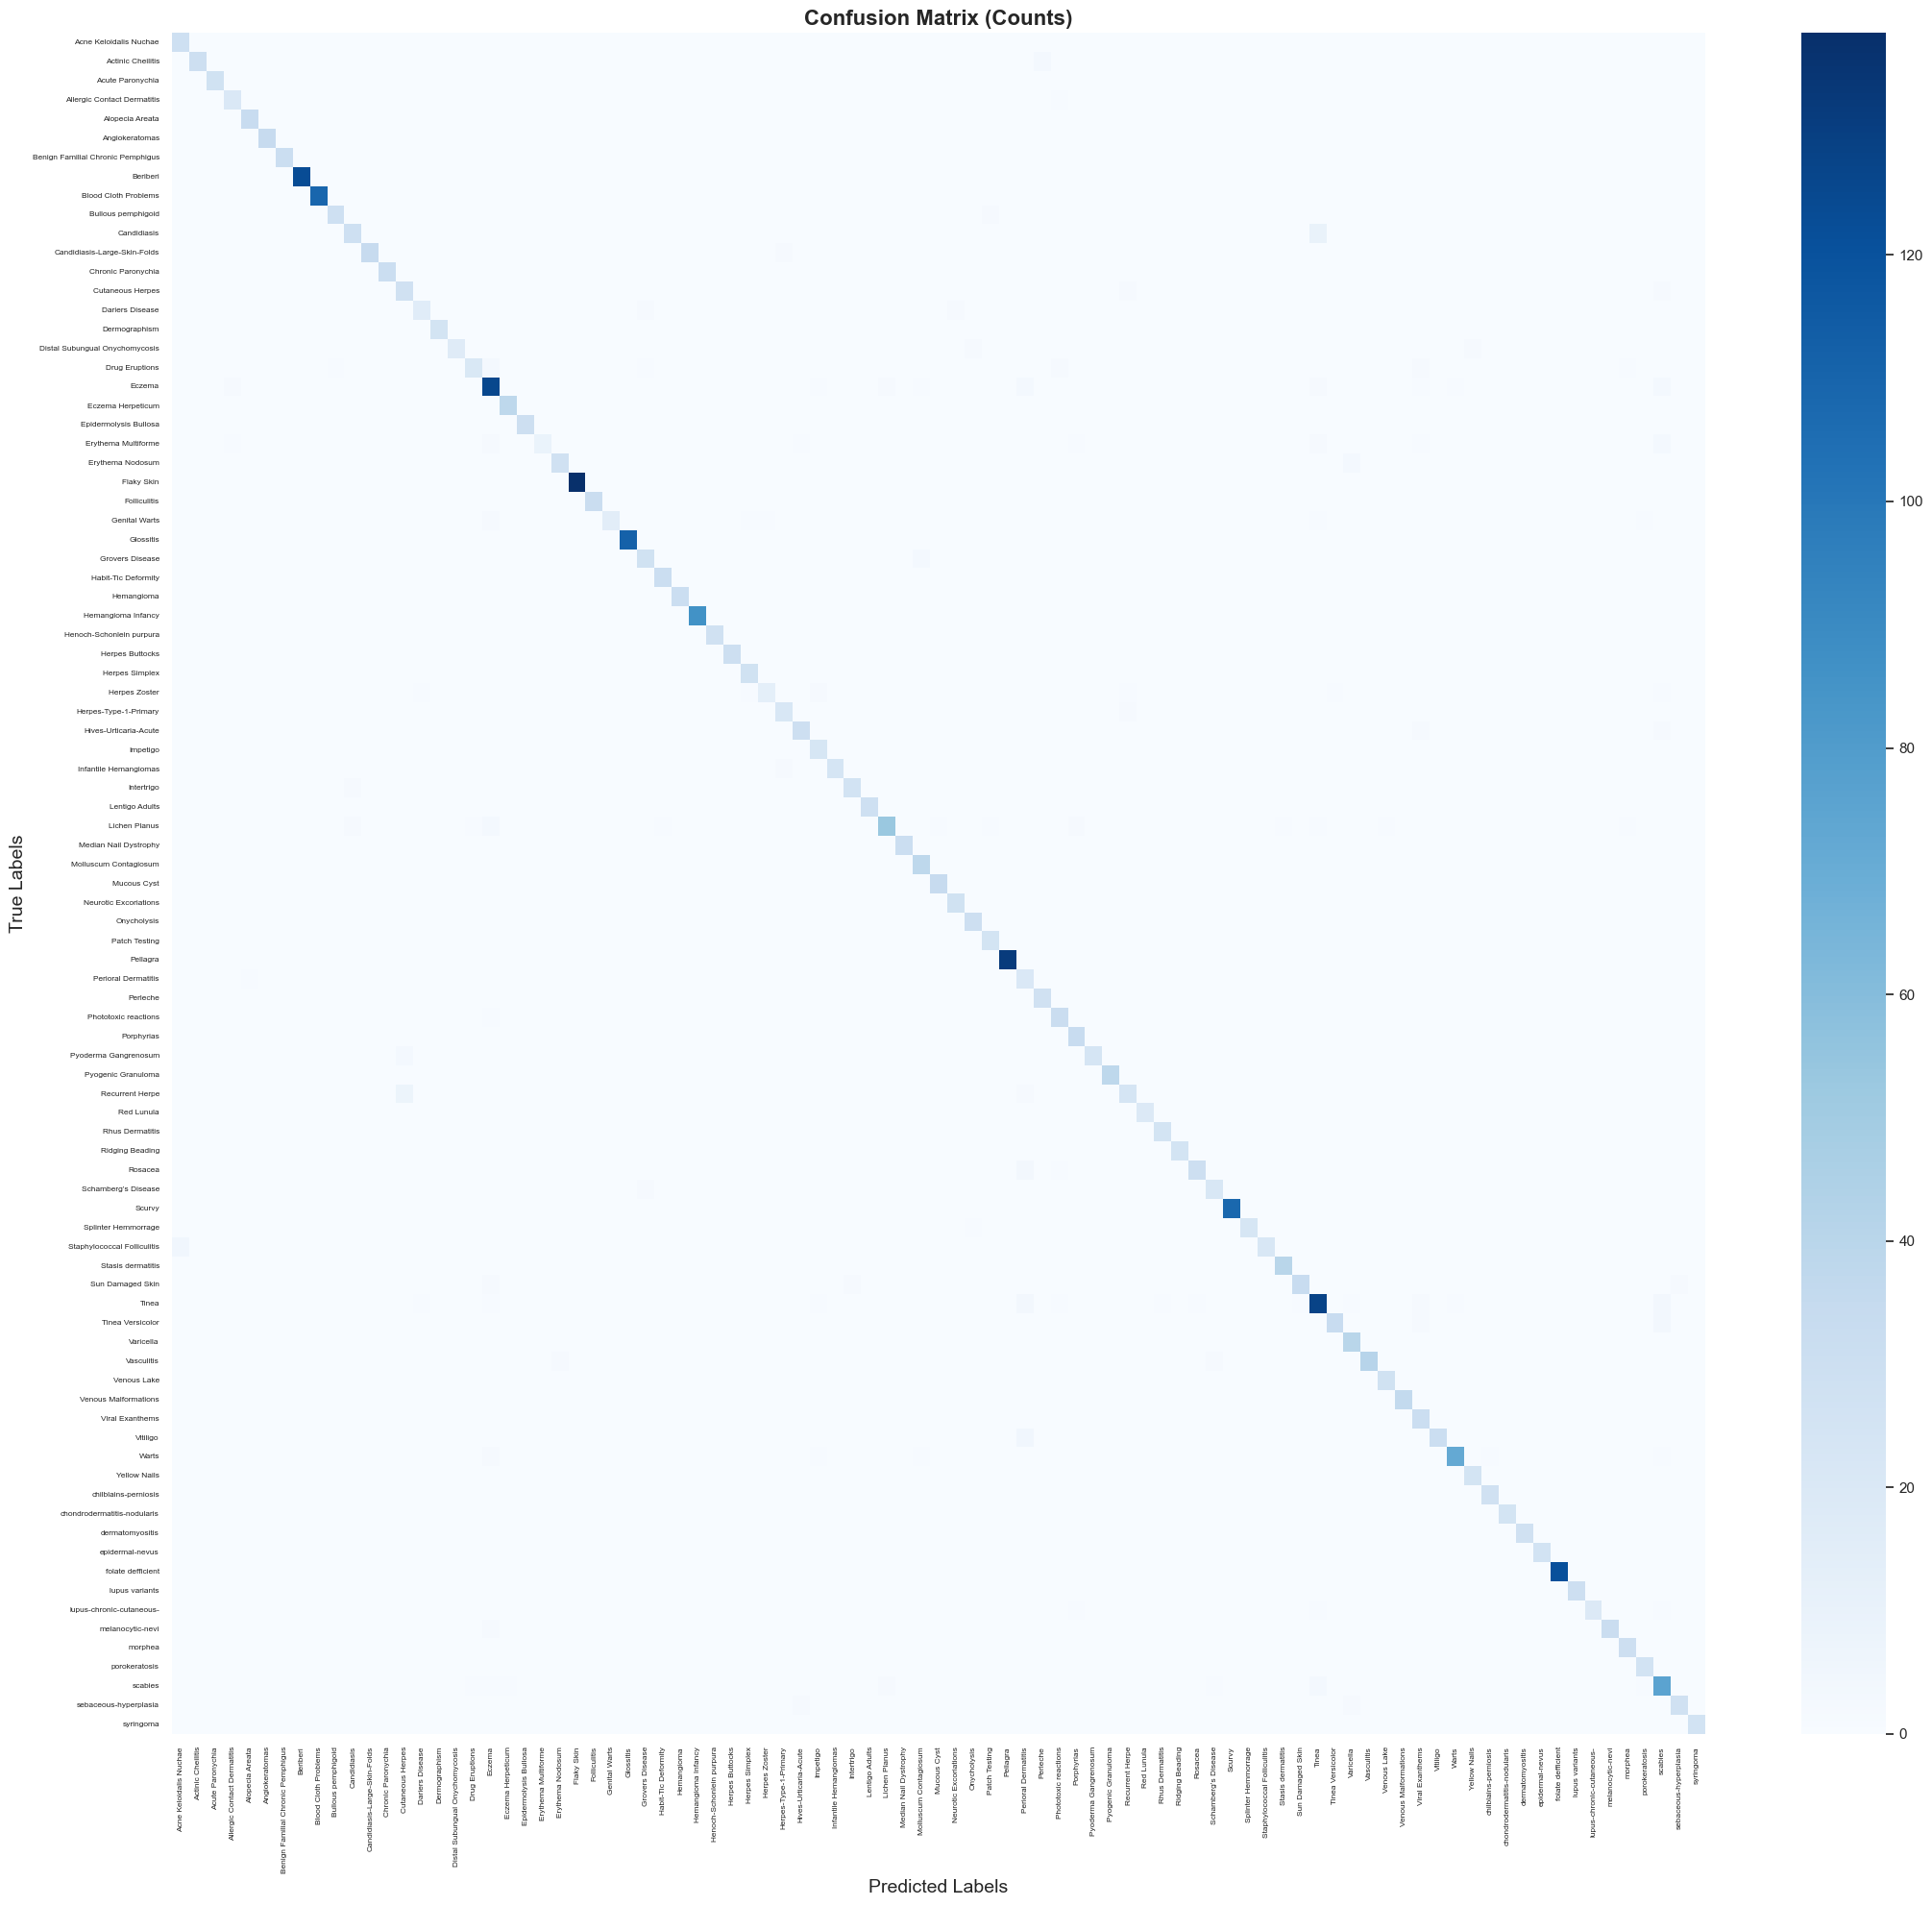

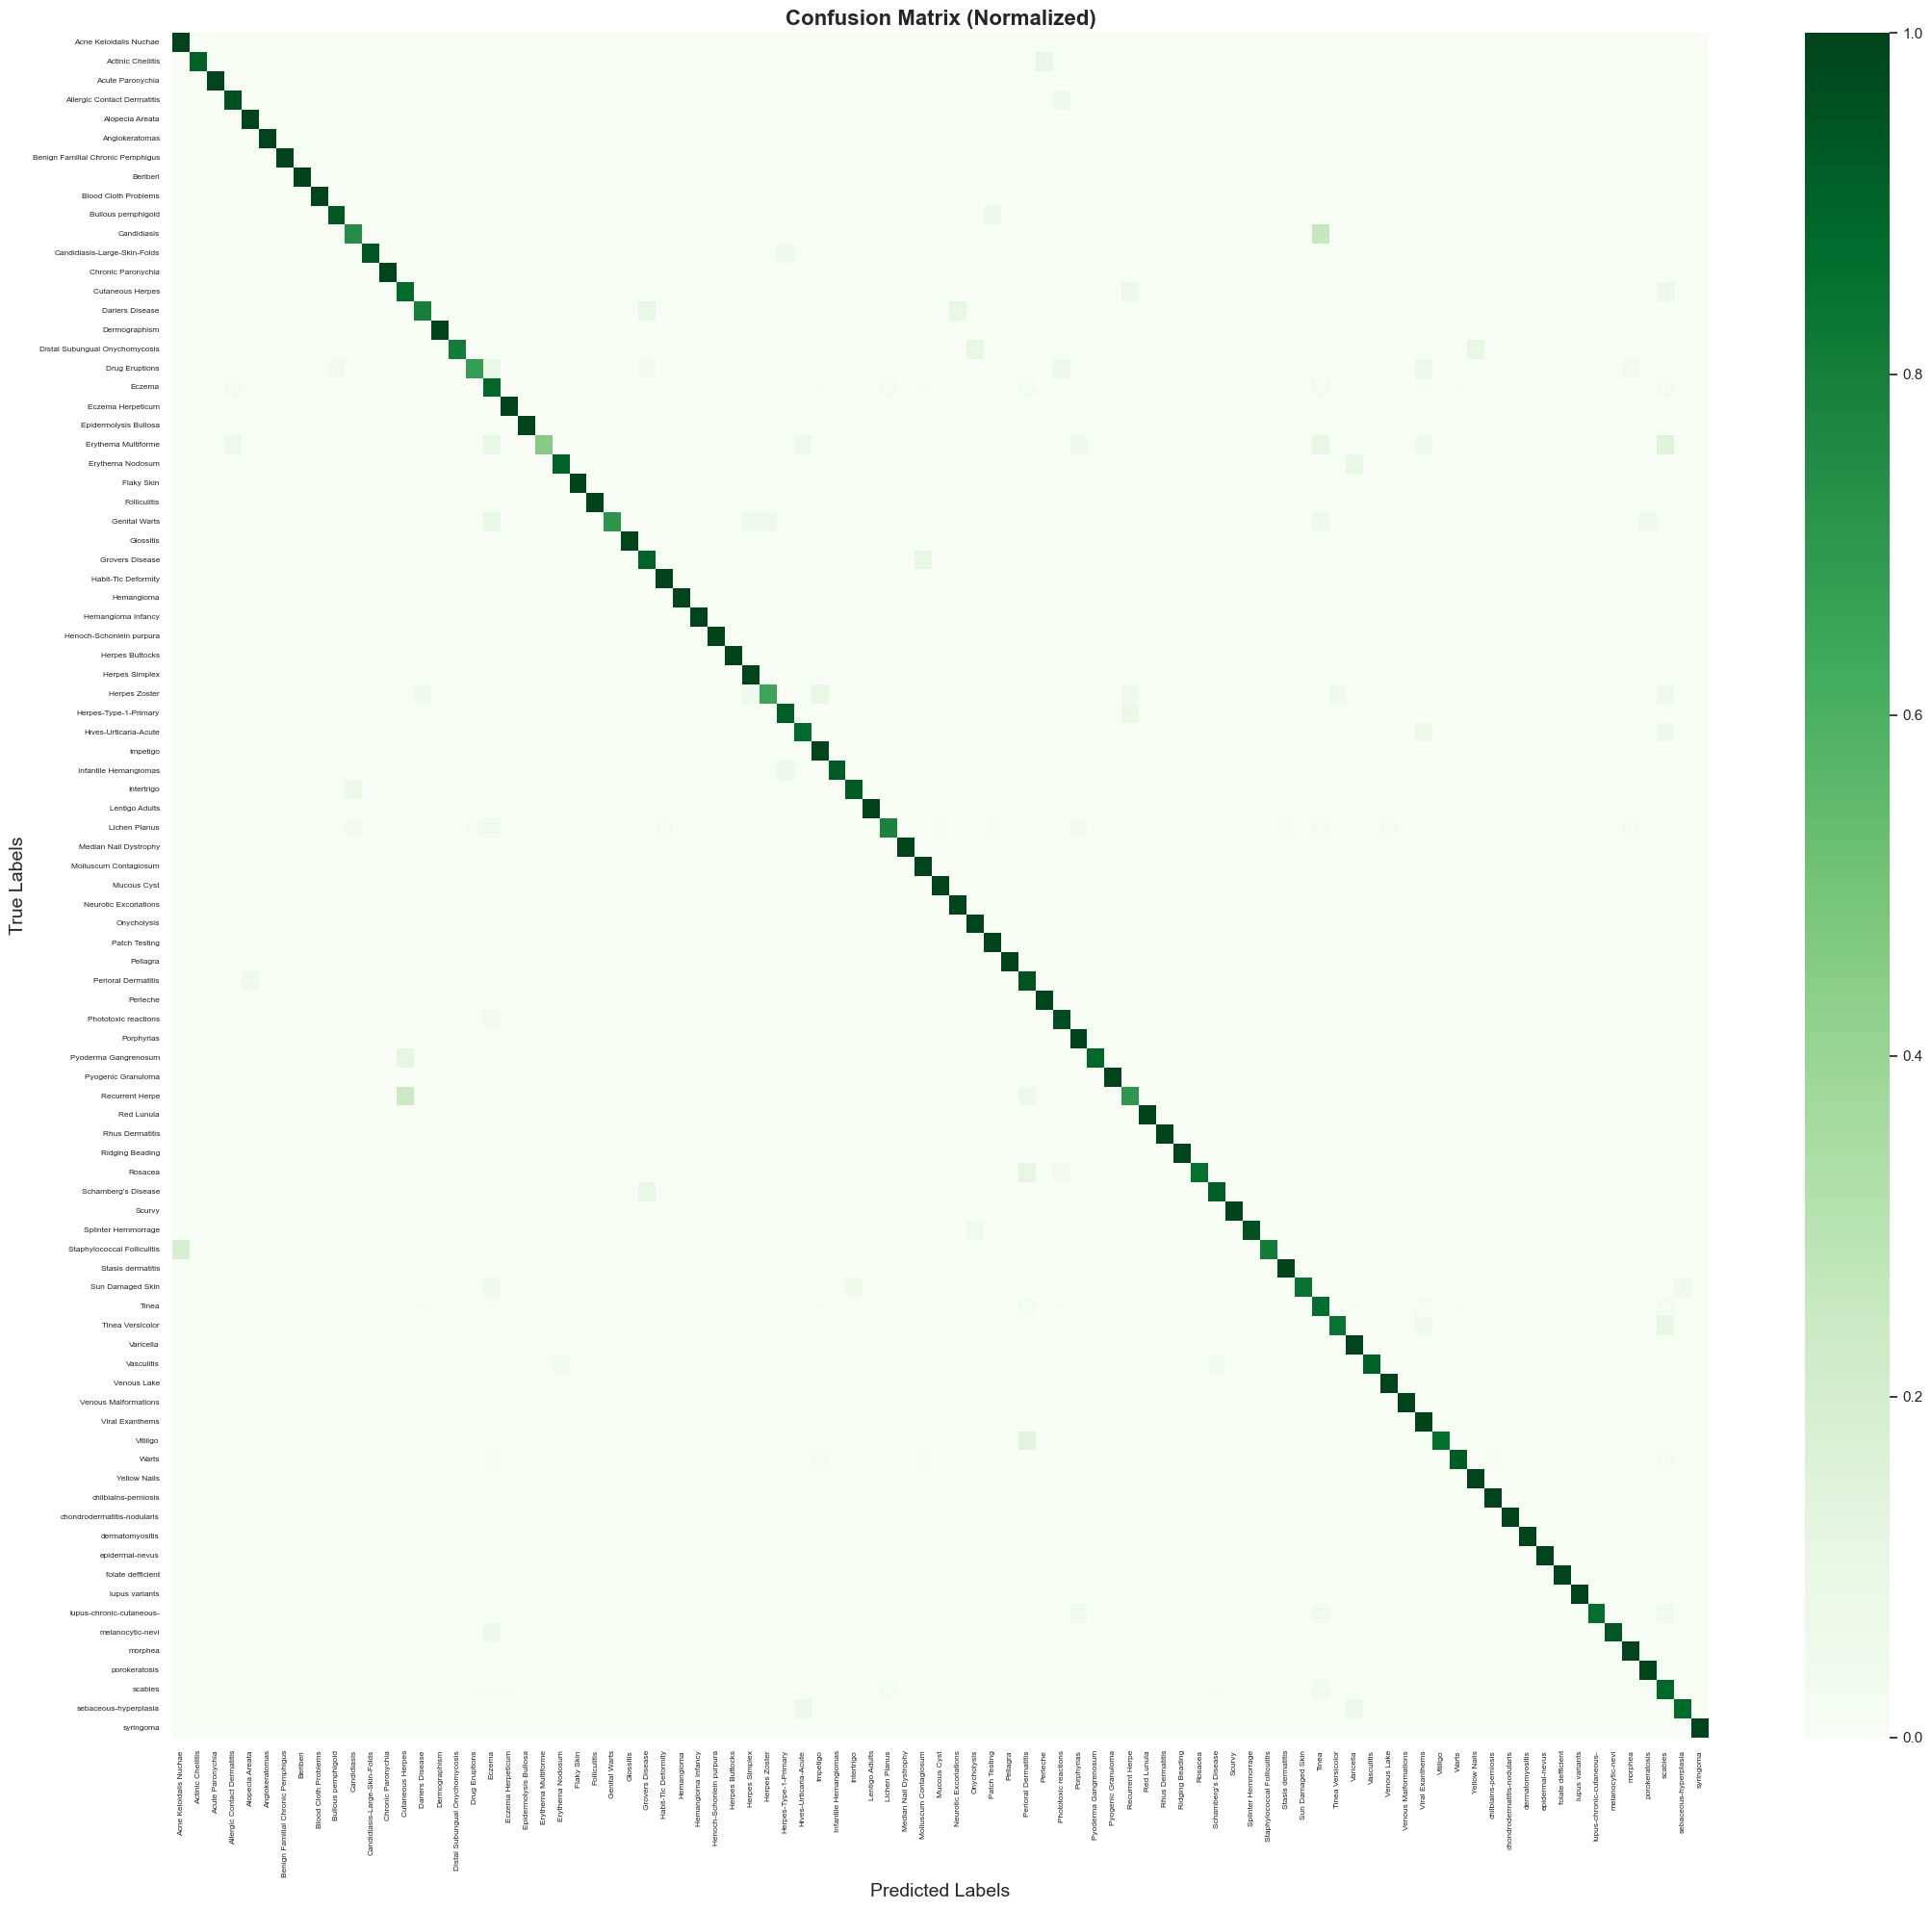


DETAILED CLASSIFICATION REPORT
                                   precision    recall  f1-score   support

           Acne Keloidalis Nuchae     0.8529    1.0000    0.9206        29
                Actinic Cheilitis     1.0000    0.9091    0.9524        33
                 Acute Paronychia     1.0000    1.0000    1.0000        27
      Allergic Contact Dermatitis     0.8696    0.9524    0.9091        21
                  Alopecia Areata     0.9706    1.0000    0.9851        33
                   Angiokeratomas     1.0000    1.0000    1.0000        34
Benign Familial Chronic Pemphigus     1.0000    1.0000    1.0000        31
                         Beriberi     1.0000    1.0000    1.0000       123
             Blood Cloth Problems     1.0000    1.0000    1.0000       109
               Bullous pemphigoid     0.9667    0.9355    0.9508        31
                      Candidiasis     0.8788    0.7436    0.8056        39
     Candidiasis-Large-Skin-Folds     1.0000    0.9444    0.9714   

In [18]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

model_path = "./Backend/Model/vitamin_deficiency_model.h5"           # Your trained model file
class_file = "./Backend/Model/class.json"     # Your saved class mapping
data_path = "./Backend/DataSet"             # Dataset folder
img_height, img_width = 224, 224
batch_size = 32
validation_split = 0.2

print("🧠 Loading model...")
model = load_model(model_path, compile=False)
print(f"✅ Model loaded successfully from: {model_path}")

# Load class names
with open(class_file, 'r') as f:
    class_names = json.load(f)
print(f"✅ Loaded {len(class_names)} class names from: {class_file}")

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=validation_split)
val_generator = val_datagen.flow_from_directory(
    data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

y_true = val_generator.classes
num_classes = len(class_names)

# ============================================
# RUN PREDICTIONS
# ============================================
print("\n🔍 Predicting on validation set...")
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

# ============================================
# METRICS
# ============================================
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Classes: {num_classes}")
print(f"Validation Samples: {len(y_true)}")

# ============================================
# CONFUSION MATRICES
# ============================================
print("\n📊 Generating Confusion Matrices...")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# --------------------------------------------
# 1️⃣ Confusion Matrix - COUNTS
# --------------------------------------------
plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Counts)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=14)
plt.ylabel("True Labels", fontsize=14)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

# --------------------------------------------
# 2️⃣ Confusion Matrix - NORMALIZED
# --------------------------------------------
plt.figure(figsize=(22, 20))
sns.heatmap(cm_normalized, annot=False, cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Normalized)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=14)
plt.ylabel("True Labels", fontsize=14)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


## Image Prediction from Dataset


🧩 Found 109 images in 'Perioral Dermatitis'
🖼 Showing predictions for 20 images from 'Perioral Dermatitis'...
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


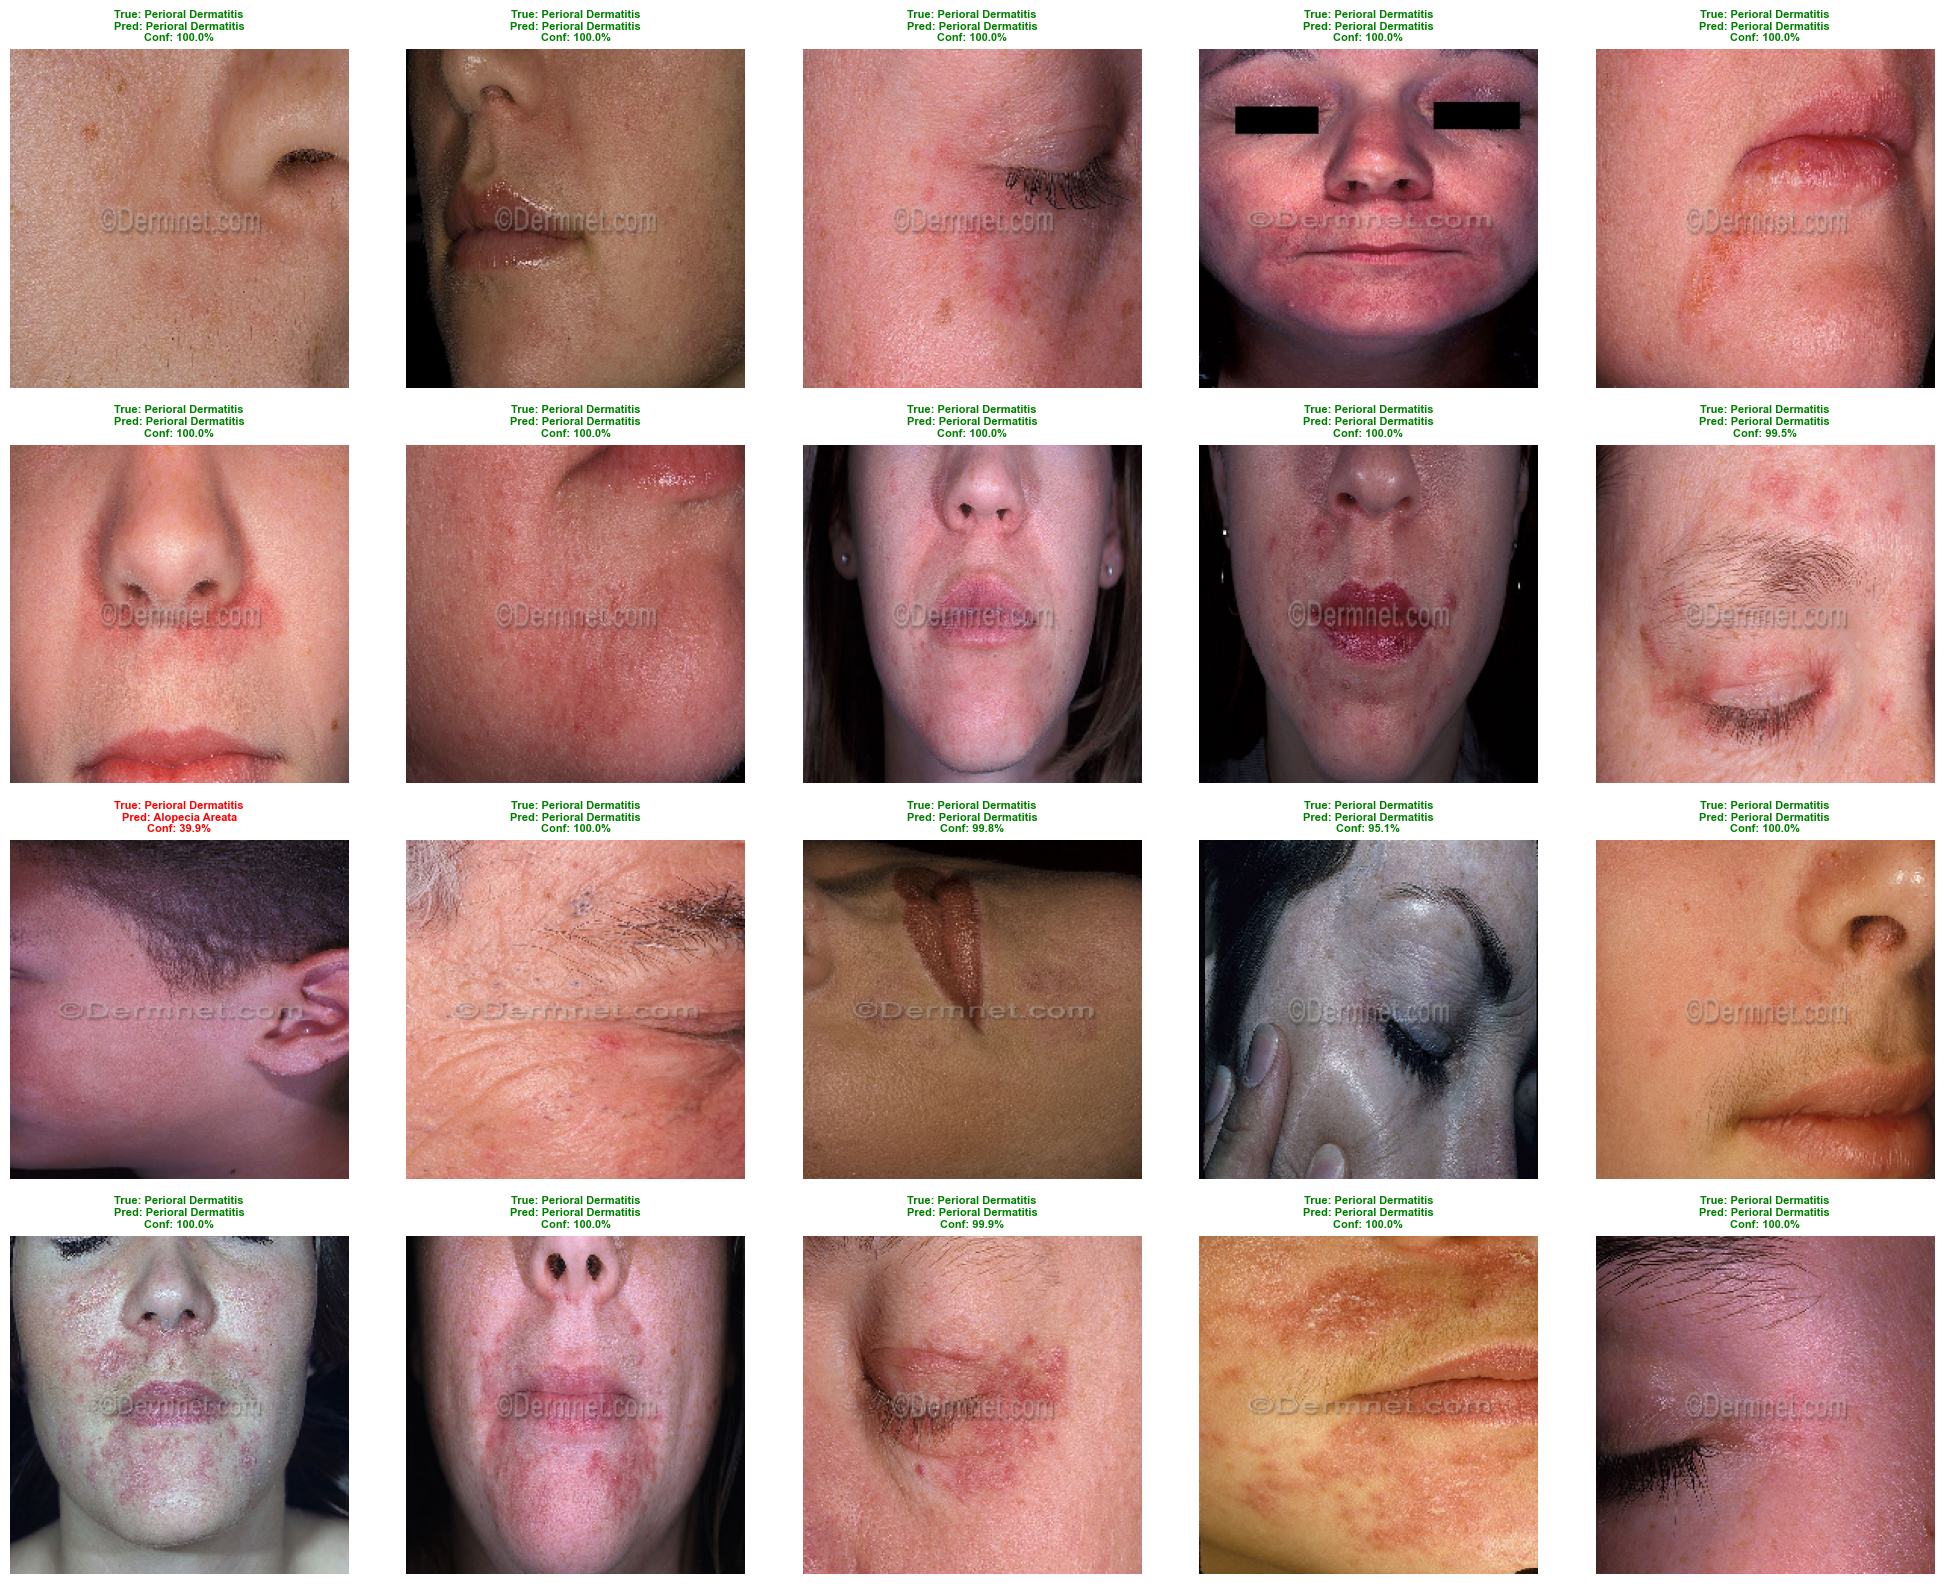

✓ Sample predictions visualized for target class.


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 🎯 Target class
target_class = "Perioral Dermatitis"

# Get the folder path for that class
target_path = os.path.join(data_path, target_class)

# Get image file list
image_files = [
    os.path.join(target_path, f)
    for f in os.listdir(target_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print(f"\n🧩 Found {len(image_files)} images in '{target_class}'")

# Load up to 20 sample images
sample_images = image_files[:20]
print(f"🖼 Showing predictions for {len(sample_images)} images from '{target_class}'...")

# Load and preprocess each image manually
img_array = []
for img_path in sample_images:
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_height, img_width))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = img / 255.0  # Rescale
    img_array.append(img)

img_array = np.array(img_array)

# Get predictions
predictions = model.predict(img_array)
pred_labels = [class_names[np.argmax(pred)] for pred in predictions]
confidences = [np.max(pred) * 100 for pred in predictions]

# Plot
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.ravel()

for i in range(len(sample_images)):
    axes[i].imshow(img_array[i])
    
    pred_label = pred_labels[i]
    confidence = confidences[i]
    
    color = 'green' if pred_label == target_class else 'red'
    axes[i].set_title(
        f'True: {target_class}\nPred: {pred_label}\nConf: {confidence:.1f}%',
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("✓ Sample predictions visualized for target class.")


In [13]:
%pip install ipywidgets pandas fuzzywuzzy python-Levenshtein opencv-python-headless tqdm --quiet

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import time
from tqdm.notebook import tqdm
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import ipywidgets as widgets
from IPython.display import display, clear_output
from fuzzywuzzy import process

# --------------------------------------------------
# Configuration
# --------------------------------------------------
model_path = "./Backend/Model/vitamin_deficiency_model.h5"
class_file = "./Backend/Model/class.json"
csv_file = "./Backend/Model/mapping_data.csv"
img_height, img_width = 224, 224

haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# --------------------------------------------------
# Load Model
# --------------------------------------------------
print("🧠 Loading model...")
model = load_model(model_path, compile=False)
print(f"✅ Model loaded successfully from: {model_path}")

# Load class names
with open(class_file, 'r') as f:
    class_names = json.load(f)
if isinstance(class_names, dict):
    class_names = list(class_names.keys())
print(f"✅ Loaded {len(class_names)} class names from: {class_file}")

# Load disease ↔ vitamin deficiency map
vitamin_map = {}
try:
    df = pd.read_csv(csv_file)
    df.columns = [c.strip().lower() for c in df.columns]
    if "diseases" in df.columns and "deficiency" in df.columns:
        df["diseases"] = df["diseases"].str.strip().str.lower()
        vitamin_map = dict(zip(df["diseases"], df["deficiency"]))
        print(f"✅ Loaded {len(vitamin_map)} disease–vitamin mappings.")
except Exception as e:
    print("⚠️ CSV Error:", e)

# --------------------------------------------------
# UI Setup
# --------------------------------------------------
output = widgets.Output()
upload_btn = widgets.FileUpload(accept='image/*', multiple=False, description='📤 Upload')
progress_label = widgets.Label("")
progress_bar = widgets.IntProgress(min=0, max=100, value=0, bar_style='info')

# Processing state management
is_processing = False
last_processed_name = None

title = widgets.HTML("<h3>📸 Upload ONE Image for Prediction (Human Detection Enabled)</h3>")
info_label = widgets.HTML("<p style='color: #555; font-size: 11px;'>⚠️ Single image upload only. Wait for processing to complete before uploading another image.</p>")
display(widgets.VBox([title, info_label, upload_btn, progress_label, progress_bar, output]))

# --------------------------------------------------
# Upload Handler
# --------------------------------------------------
def on_upload_change(change):
    global is_processing, last_processed_name
    
    # Early exit if no upload
    if not upload_btn.value:
        return
    
    # Check if already processing
    if is_processing:
        with output:
            clear_output(wait=True)
            print("⏸️ BUSY: Currently processing an image. Please wait...")
            print("⚠️ Upload rejected to prevent duplicate processing.")
        upload_btn.value = ()  # Clear the upload
        return
    
    # Extract file info
    uploaded = upload_btn.value
    if isinstance(uploaded, tuple):
        file_info = uploaded[0]
    elif isinstance(uploaded, dict):
        file_info = next(iter(uploaded.values()))
    else:
        with output:
            clear_output(wait=True)
            print("⚠️ Unknown upload format.")
        upload_btn.value = ()
        return
    
    filename = file_info.get('name', 'uploaded_image.jpg')
    content = file_info.get('content', None)
    
    # Check if same file being re-uploaded
    if filename == last_processed_name:
        with output:
            clear_output(wait=True)
            print(f"⚠️ Image '{filename}' was already processed.")
            print("📌 Upload a different image for new prediction.")
        upload_btn.value = ()
        return
    
    if not content:
        with output:
            clear_output(wait=True)
            print("⚠️ Could not read uploaded file.")
        upload_btn.value = ()
        return
    
    # Set processing flag and disable upload
    is_processing = True
    upload_btn.disabled = True
    progress_label.value = "🔒 Processing locked..."
    
    with output:
        clear_output(wait=True)
        print(f"🔄 Processing image: {filename}")
        print("="*60)

        try:
            img = Image.open(io.BytesIO(content)).convert('RGB')
            img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

            # Face detection
            gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
            faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

            if len(faces) == 0:
                plt.imshow(img)
                plt.axis('off')
                plt.title("⚠️ No human detected! Please upload a clear face/skin image.",
                          color='red', fontsize=12)
                plt.show()
                print("🚫 Prediction aborted: No human detected.")
                print("="*60)
                upload_btn.value = ()
                is_processing = False
                upload_btn.disabled = False
                progress_label.value = ""
                progress_bar.value = 0
                return

            print(f"✅ Detected {len(faces)} human region(s). Proceeding with prediction...")

            # Simulate progress bar
            progress_label.value = "🔄 Processing image..."
            for i in tqdm(range(0, 101, 10), desc="Running model"):
                progress_bar.value = i
                time.sleep(0.05)

            # Prediction
            img_resized = img.resize((img_width, img_height))
            img_array = image.img_to_array(img_resized) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            pred_probs = model.predict(img_array, verbose=0)
            pred_idx = np.argmax(pred_probs)
            confidence = float(np.max(pred_probs) * 100)
            pred_class = class_names[pred_idx]

            # Vitamin mapping
            match, score = process.extractOne(pred_class.lower(), vitamin_map.keys()) if vitamin_map else (None, 0)
            vitamin_def = vitamin_map.get(match, "Unknown / Not Mapped") if (match and score > 70) else "Unknown / Not Mapped"

            progress_label.value = "✅ Prediction complete!"
            progress_bar.bar_style = 'success'
            progress_bar.value = 100

            # Display output
            plt.figure(figsize=(5, 5))
            plt.imshow(img)
            plt.axis('off')
            plt.title(
                f"Disease: {pred_class}\nConfidence: {confidence:.2f}%\nVitamin Deficiency: {vitamin_def}",
                fontsize=12, fontweight='bold', color='green'
            )
            plt.show()

            print("="*60)
            print("🩺 MODEL PREDICTION RESULT")
            print("="*60)
            print(f"📁 File: {filename}")
            print(f"🧠 Predicted Disease: {pred_class}")
            print(f"📊 Confidence: {confidence:.2f}%")
            print(f"💊 Vitamin Deficiency: {vitamin_def}")
            print("="*60)
            print("\n✅ Processing complete! Ready for next image.")
            
            # Update last processed
            last_processed_name = filename
            
        except Exception as e:
            print(f"❌ Error processing image: {str(e)}")
            print("="*60)
        
        finally:
            # Always reset state
            upload_btn.value = ()
            progress_bar.value = 0
            progress_bar.bar_style = 'info'
            progress_label.value = ""
            is_processing = False
            upload_btn.disabled = False

upload_btn.observe(on_upload_change, names='value')

Note: you may need to restart the kernel to use updated packages.
🧠 Loading model...


c:\Users\darsh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


✅ Model loaded successfully from: ./Backend/Model/vitamin_deficiency_model.h5
✅ Loaded 89 class names from: ./Backend/Model/class.json
✅ Loaded 88 disease–vitamin mappings.
